<a href="https://colab.research.google.com/github/aastha3399/ML_Lab_2026/blob/main/ML_EXP9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("Cancer_Data.csv")

# Remove unnecessary columns
data = data.drop(["id", "Unnamed: 32"], axis=1)


In [ ]:
# Convert diagnosis
# B = 0, M = 1
data["diagnosis"] = data["diagnosis"].map({"B": 0, "M": 1})

# Use two features for simple visualization
X = data[["radius_mean", "texture_mean"]].values
y = data["diagnosis"].values

# Convert labels to -1 and +1
y = np.where(y == 0, -1, 1)

In [ ]:
# Normalize features
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Split data
np.random.seed(42)

indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))

train = indices[:train_size]
test = indices[train_size:]

X_train = X[train]
X_test = X[test]

y_train = y[train]
y_test = y[test]

In [ ]:
# -----------------------------
# Linear SVM
# -----------------------------

w = np.zeros(X_train.shape[1])
b = 0

learning_rate = 0.001
C = 1
epochs = 1000

for epoch in range(epochs):

    for i in range(len(X_train)):

        condition = y_train[i] * (np.dot(X_train[i], w) + b)

        if condition >= 1:
            w = w - learning_rate * 2 * w

        else:
            w = w - learning_rate * (
                2 * w - C * y_train[i] * X_train[i]
            )

            b = b + learning_rate * C * y_train[i]


# Prediction
def predict(X):
    return np.where(np.dot(X, w) + b >= 0, 1, -1)


y_pred = predict(X_test)


# Accuracy
accuracy = np.mean(y_pred == y_test) * 100

print("Linear SVM Accuracy:",
      round(accuracy, 2), "%")

Linear SVM Accuracy: 60.53 %


In [ ]:
# -----------------------------
# Confusion Matrix
# -----------------------------

TP = np.sum((y_test == 1) & (y_pred == 1))
TN = np.sum((y_test == -1) & (y_pred == -1))
FP = np.sum((y_test == -1) & (y_pred == 1))
FN = np.sum((y_test == 1) & (y_pred == -1))

print("\nConfusion Matrix")
print("----------------")
print([[TN, FP],
       [FN, TP]])


Confusion Matrix
----------------
[[np.int64(67), np.int64(0)], [np.int64(45), np.int64(2)]]


In [ ]:
# -----------------------------
# Support Vectors
# -----------------------------

decision_values = y_train * (
    np.dot(X_train, w) + b
)

support_vectors = X_train[
    (decision_values >= 0.9) &
    (decision_values <= 1.1)
]

print("\nNumber of Support Vectors:",
      len(support_vectors))




Number of Support Vectors: 153


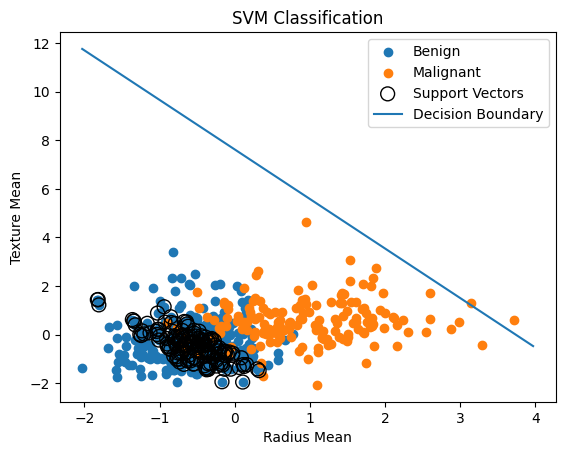

In [ ]:
import matplotlib.pyplot as plt

# -----------------------------
# Decision Boundary
# -----------------------------

plt.scatter(
    X_train[y_train == -1, 0],
    X_train[y_train == -1, 1],
    label="Benign"
)

plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    label="Malignant"
)

# Support vectors
if len(support_vectors) > 0:
    plt.scatter(
        support_vectors[:, 0],
        support_vectors[:, 1],
        s=100,
        facecolors="none",
        edgecolors="black",
        label="Support Vectors"
    )

# Decision boundary
x_values = np.linspace(
    X[:, 0].min(),
    X[:, 0].max(),
    100
)

y_values = -(w[0] * x_values + b) / w[1]

#print("x_values : ", x_values)
#print("y_values : ", y_values)

plt.plot(
    x_values,
    y_values,
    label="Decision Boundary"
)

plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.title("SVM Classification")
plt.legend()
plt.show()